# Pattern Similarity Analyses (Category Similarity and Category Evidence)

Subject 51 is excluded from analyses involving the learning runs due to a bug in data acquisition.

## 0. Initialization

In [1]:
import warnings
import sys 
if not sys.warnoptions:
    warnings.filterwarnings("ignore", category=DeprecationWarning)
import os 
import random
import nibabel as nib
import numpy as np
import pandas as pd

import scipy.io
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns 
from itertools import combinations

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects import Formula

from utils import *


In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

SMALL_SIZE = 12
MEDIUM_SIZE = 15
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [3]:
subinfo = pd.read_csv('./data/subject_info.txt', sep="\t")

excl_thresh = int(np.round((21*3)*0.6))
usable_subinfo = subinfo[subinfo.fmri_scenes_usable == 1].reset_index(drop=True)
usable_subinfo = usable_subinfo[usable_subinfo.encoded_pairs >= excl_thresh].reset_index(drop=True)
learn_usable_subinfo = usable_subinfo[usable_subinfo.subid != 51].reset_index(drop=True) 

subIDs = list(usable_subinfo.subid)
ctrl_subIDs = list(usable_subinfo[usable_subinfo.group == 0].subid)
stress_subIDs = list(usable_subinfo[usable_subinfo.group == 1].subid)

learn_subIDs = list(learn_usable_subinfo.subid)
learn_ctrl_subIDs = list(learn_usable_subinfo[learn_usable_subinfo.group == 0].subid)
learn_stress_subIDs = list(learn_usable_subinfo[learn_usable_subinfo.group == 1].subid)

grpnum2name = {0: "Control", 1: "Stress"}
sub2grp = {usable_subinfo.iloc[i]["subid"]: grpnum2name[usable_subinfo.iloc[i]["group"]] for i in range(len(usable_subinfo))}
sub2grp_df = usable_subinfo[["subid", "group"]]
sub2grp_df["group"] = sub2grp_df["group"].apply(lambda x: grpnum2name[x])

groups = ["Control", "Stress"]
conds = ["A", "B", "X"]
cmap = plt.get_cmap("plasma")

print(len(usable_subinfo))

88


## 1. Data Loading

In [4]:
masked_outdir = "./data/masked_fmri"

def load_masked_data(subid, run, roi):
    """
    Loads in data for a given subject, run, and ROI
    Args:
        subid (int): subject ID
        run (string): scene run label
        roi (string): ROI name
    Returns:
        (np.array): masked voxel data with shape (TRs, voxels)
    """
    
    datafile = f'{masked_outdir}/{roi}/masked_{roi}_sub{subid}_{run}.npy'
    data = np.load(datafile)

    return data


def normalize_bold(bold_data_run):
    '''
    Normalize BOLD data; within each run, each voxel should have mean 0 and std 1 across TRs
    Args:
        bold_data_run (np.array): should have dimensions (TRs, voxels)
    '''
    bold_std = np.std(bold_data_run, axis=0)
    bold_normalized = (bold_data_run - np.mean(bold_data_run, axis = 0))/bold_std
    
    return bold_normalized


def get_TRlabels(subid, run, exclude_noresp=True, nan_noresp=False, labeltype="gen", shift=3, numTRs=275):
    '''
    Returns hemodynamic-shifted labels - one per TR. exclude_noresp and nan_noresp are fed into get_X_labels functions; 
    In this case, True-False is functionally equivalent to False-True (but False-False will result in no-response trials also being included)
    
    Args:
        subid (int): subject id
        run (int): run number (scene runs only)
        labeltype (str): one of ["gen", "ABX", "category"]
        shift (int): number of TRs to shift labels based on hemodynamic response (default=3)
        numTRs (int): number of TRs in the run (in general, this should be 254 but default=275 as some have more)
        
    Returns:
        list of labels (strings) associated with each TR, with 3TR hemodynamic shift built in 
    '''
    
    ABX = get_ABX_labels(subid, run, exclude_noresp=exclude_noresp, nan_noresp=nan_noresp)
    category = get_category_labels(subid, run, exclude_noresp=exclude_noresp, nan_noresp=nan_noresp)
    stimTRs = get_stimulus_TRs(subid, run, exclude_noresp=exclude_noresp)
    l2g = labels2gencats(subid)

    out_labels = None

    gencats = [l2g[c] for c in category]
    allTR_labels = ['ISI']*numTRs
    for i in range(len(stimTRs)):
        # for subject 51, the scan was short some TRs. Break out of this function if stimTRs exceeds the total length of the scan
        if stimTRs[i] + shift >= numTRs:
            print(f'Subject {subid} run {run} too few TRs; continuing with available data')
            break
        
        if labeltype == "gen":
            allTR_labels[stimTRs[i]+shift] = gencats[i]
        elif labeltype == "ABX":
            allTR_labels[stimTRs[i]+shift] = ABX[i]
        elif labeltype == "category":
            allTR_labels[stimTRs[i]+shift] = category[i]
    
    return allTR_labels


def get_trial_data(subid, run, roi, trialtype, exclusive=False, shift=3):
    '''
    Returns BOLD data associated with particular trials
    Args:
        subid (int): subject ID number
        run (str): run name
        roi (str): roi name
        trialtype (list(str)): subset of ["A", "B", "X", "A1".."A3", "B1".."B3", "X1..X6", {category names}]
        exclusive (bool): if True, returns trials excluding the ones listed in trialtype (default: False)
        shift (int): number of TRs to shift to account for hemodynamic response
    Returns:
        np.array with shape (TRs, voxels), including only the data associated with the input trialtypes
        list(str): list of trialtypes in the output
    '''
    
    run_num = int(run[-1])
    
    # initialize constants
    ABX_trialtypes = ["A", "B", "X"]
    gen_trialtypes = [f"A{i}" for i in range(1, 4)] + [f"B{i}" for i in range(1, 4)] + [f"X{i}" for i in range(1, 7)]
    category_trialtypes = ['beaches', 'bridges', 'canyons', 'deserts', 'fields', 'forests', 'lakes', 'lighthouses', 'marshes', 'mountains', 'parks', 'waterfalls']
    
    # load in and normalize data for this sub and run
    data = load_masked_data(subid, run, roi)
    norm_data = normalize_bold(data)
    numTRs, numvoxs = norm_data.shape
    
    # check to see if everything in gen_trial_data is from the same general trial type (ABX, gen, or category)
    if np.product(np.isin(trialtype, ABX_trialtypes)):
        labeltype = "ABX"
        all_trialtypes = ABX_trialtypes.copy()
    elif np.product(np.isin(trialtype, gen_trialtypes)):
        labeltype = "gen"
        all_trialtypes = gen_trialtypes.copy()
    elif np.product(np.isin(trialtype, category_trialtypes)):
        labeltype = "category"
        all_trialtypes = category_trialtypes.copy()
    else:
        raise Exception("All elements of trialtype must be the same type of trial; ABX, category, or gen") 
        
    TR_labels = get_TRlabels(subid, run_num, exclude_noresp=True, nan_noresp=False, labeltype=labeltype, shift=shift, numTRs=numTRs)
    
    # find the TRs (rows) that match trialtype
    if not exclusive:
        TRs = np.where(np.isin(TR_labels, trialtype))[0]
    else:
        for s in trialtype:
            all_trialtypes.remove(s)
        TRs = np.where(np.isin(TR_labels, all_trialtypes))[0]
    
    # extract the TRs from the data
    trial_data = norm_data[TRs,:]
    
    out_trialtypes = trialtype if not exclusive else all_trialtypes
    
    return trial_data, out_trialtypes, TRs


def get_behav_recog_df(sub, conf_thr, runs, overwrite=False):
    '''
    Get trial-level behavioral recognition data
    '''
    
    recog_outfile = f"./midpoints/trial_recog/sub{sub}_trialwise_behav_recog_runs{''.join([r[-1] for r in runs])}_confthr{conf_thr}.csv"
    
    if overwrite or not os.path.isfile(recog_outfile):
        behav_file = f'./data/behavior/catStats_sub{sub}.csv'
        behav_df = pd.read_csv(behav_file, sep='\t')

        # filter to only the desired runs
        behav_df = behav_df.loc[(np.isin(behav_df["block"], [int(r[-1]) for r in runs]))].reset_index(drop=True)

        # add a column for category repetition number (how many times have we seen this category)
        catrep_count = {c: 0 for c in np.unique(behav_df["category"])}
        repcol = []
        for i in range(len(behav_df)):
            curcat = behav_df.iloc[i]["category"]
            catrep_count[curcat] += 1
            repcol.append(catrep_count[curcat])
        behav_df["repetition"] = repcol

        # filter to only encoded
        behav_df = behav_df[(behav_df["encoded"] == 1)]

        # modify category column to gencat
        behav_df["trialtype"] = behav_df["category"].apply(lambda x: labels2gencats(sub)[x])

        # shift TR column by 3 for hemodynamic shift
        behav_df["TR"] = behav_df["TR"] + 3

        # modify block, recog, group column
        behav_df["run"] = behav_df["block"].apply(lambda x: f'scene{x}')
        behav_df["group"] = behav_df["group"].apply(lambda x: {0: 'Control', 1: 'Stress'}[x])
        
        if "scene1" not in runs and "scene5" not in runs:
            behav_df["recog"] = behav_df["recogAcc"].apply(lambda x: {0: 'forgotten', 1: 'remembered'}[x])
            recog_df = behav_df[["subid", "group", "run", "TR", "trialtype", "recog", "repetition"]]
        else:
            recog_df = behav_df[["subid", "group", "run", "TR", "trialtype", "repetition"]]
        
        recog_df.to_csv(recog_outfile, index=False)

    else:
        recog_df = pd.read_csv(recog_outfile)
        
    return recog_df


## 2. Helper Functions

In [5]:
def get_vec_match_idx(vec1, vec2):
    '''
    Find indices where two vectors have matching values.
    '''
    match_pairs = []
    for i in range(len(vec1)):
        for j in range(len(vec2)):
            if vec1[i] == vec2[j]:
                match_pairs.append((i, j))

    return match_pairs


def trialwise_corrseries(subid, roi, match_runs, cur_runs, match_trialtypes, cur_trialtypes, savedir=None, shift=3):
    '''
    Computes a correlation matrix between two groups of TRs (from a match run and a current run), 
    then averages over TRs in the match run (producing a series), saving out the resulting series with a unique filename
    
    Args:
        subid (int): subject id
        roi (str): ROI name
        match_runs (list(str)): match run name (or a list of runs, data from which would be concatenated together)
        cur_runs (list(str)): current run name (or a list of runs, data from which would be concatenated together)
        match_trialtypes (list(str)): subset of ["A", "B", "X", "A1".."A3", "B1".."B3", "X1..X6", {category names}] OR None; if None, uses all TRs by default
        cur_trialtypes (list(str)): subset of ["A", "B", "X", "A1".."A3", "B1".."B3", "X1..X6", {category names}] OR None; if None, uses all TRs by default
        savedir (str): directory to save the output; default = None (doesn't save the output)
        shift (int): hemodynamic shift as a number of TRs (default=3)

    Returns:
        np.array with shape (, cur_TRs): a series of values reflecting the degree to which each trial in the cur_run correlates with the trials in the match_run
        
    '''
    
    # restructure match_runs and cur_runs as lists if they are single run strings
    if type(match_runs) is not list:
        match_runs = [match_runs]
    if type(cur_runs) is not list:
        cur_runs = [cur_runs]
        
    # find if there is any overlap between match_runs and cur_runs; correlations between 2 instances of same image must be removed
    samerunidxpairs = get_vec_match_idx(match_runs, cur_runs)

    # get the match data
    match_data_all = []
    match_TRs_all = []
    for match_run in match_runs:
        if match_trialtypes is not None:
            match_data, match_out_trialtypes, match_TRs = get_trial_data(subid, match_run, roi, match_trialtypes, exclusive=False, shift=shift)
        else:
            match_data = normalize_bold(load_masked_data(subid, match_run, roi))
            match_out_trialtypes = None
            match_TRs = np.arange(match_data.shape[0])

        
        match_data_all.append(match_data)
        match_TRs_all.append(match_TRs)
            
    match_data = np.vstack(match_data_all)
        
    # get the cur run data
    cur_data_all = []
    cur_TRs_all = []
    for cur_run in cur_runs:
        if cur_trialtypes is not None:
            cur_data, cur_out_trialtypes, cur_TRs = get_trial_data(subid, cur_run, roi, cur_trialtypes, exclusive=False, shift=shift)
        else:
            cur_data = normalize_bold(load_masked_data(subid, cur_run, roi))
            cur_out_trialtypes = None
            cur_TRs = np.arange(cur_data.shape[0])

        cur_data_all.append(cur_data)
        cur_TRs_all.append(cur_TRs)
        
    cur_data = np.vstack(cur_data_all)
    
    # any nan values in the BOLD data at this point indicates a bad voxel, which should be removed from both match and cur data
    good_voxs = ~np.any(np.isnan(match_data), axis=0)*~np.any(np.isnan(cur_data), axis=0)
    match_data = match_data[:,good_voxs]
    cur_data = cur_data[:,good_voxs]

    # compute the correlation matrix with shape (matchTRs, curTRs)
    n_matchTRs, n_matchvoxs = match_data.shape
    n_curTRs, n_curvoxs = cur_data.shape
    rsm = np.corrcoef(match_data, cur_data)[:n_matchTRs, n_matchTRs:]
    
    
    # If there is overlap between match_runs and cur_runs, check for overlapping TRs within matching runs, identify array indices to remove (nan), and nan them out of RSM
    nan_matchidxs = []
    nan_curidxs = []
    match_TR_counts_all = [len(a) for a in match_TRs_all]
    cur_TR_counts_all = [len(a) for a in cur_TRs_all]
    match_TR_pads = np.cumsum([0] + match_TR_counts_all)
    cur_TR_pads = np.cumsum([0] + cur_TR_counts_all)
    
    for srpair in samerunidxpairs:
        srpair_match_TRs = match_TRs_all[srpair[0]]
        srpair_cur_TRs = cur_TRs_all[srpair[1]]
        
        srpair_sameTRidx = np.array(get_vec_match_idx(srpair_match_TRs, srpair_cur_TRs)).T
        if len(srpair_sameTRidx) > 0:
            nan_matchidxs += list(srpair_sameTRidx[0] + match_TR_pads[srpair[0]])
            nan_curidxs += list(srpair_sameTRidx[1] + cur_TR_pads[srpair[1]])
    
    rsm[(nan_matchidxs, nan_curidxs)] = np.nan
        
        
    # average over the TRs in the match run (ignoring nans)
    mean_corr_series = np.nanmean(rsm, axis=0)
    
    # save out the resulting series
    if savedir is not None:
        matchstr = ''.join(match_out_trialtypes) if match_out_trialtypes is not None else 'None'
        curstr = ''.join(cur_out_trialtypes) if cur_out_trialtypes is not None else 'None'
        
        savefile = f'{savedir}/corrseries_{subid}_{roi}_match{match_run}_{matchstr}_cur{cur_run}_{curstr}_shift{shift}.npy'
        np.save(savefile, mean_corr_series)
    else:
        savefile = None
        
    return mean_corr_series, [match_TRs_all, cur_TRs_all]
    
    
def sub_trialwise_coherence(sub, roi, cond, match_runs, cur_runs, overwrite=False):
    '''
    Get within-category and between-category category similarity for a single subject
    Args:
        sub (int): subject id
        roi (str): ROI name
        match_runs (list(str)): match run name (or a list of runs, data from which would be concatenated together)
        cur_runs (list(str)): current run name (or a list of runs, data from which would be concatenated together)
    '''
    
    trial_coherence_outfile = f"./midpoints/trial_category_coherence/sub{sub}_{roi}_{cond}_match{''.join([r[-1] for r in match_runs])}_cur{''.join([r[-1] for r in cur_runs])}_trialwise_coherence.csv"
    
    if overwrite or not os.path.isfile(trial_coherence_outfile):
        cond2trialtypes = {"A": [f"A{i+1}" for i in range(3)], 
                           "B": [f"B{i+1}" for i in range(3)], 
                           "X": [f"X{i+1}" for i in range(6)]}
        trialtypes = cond2trialtypes[cond]

        match_trial_coherence_df = {'subid': [], 'run': [], 'TR': [], 'trialtype': [], 'match_coherence': []}
        nonmatch_trial_coherence_df = {'subid': [], 'run': [], 'TR': [], 'trialtype': [], 'nonmatch_coherence': []}

        for trialtype in trialtypes:
            # compute coherence with matching category
            corrseries, [_, cur_TRs] = trialwise_corrseries(sub, roi, match_runs, cur_runs, match_trialtypes = [trialtype], cur_trialtypes = [trialtype], savedir=None, shift=3)

            # save match coherence info in corresponding df
            match_trial_coherence_df['subid'] += [sub]*len(corrseries)
            for run, run_TRs in zip(cur_runs, cur_TRs):
                match_trial_coherence_df['run'] += [run]*len(run_TRs)
                match_trial_coherence_df['TR'] += list(run_TRs)
            match_trial_coherence_df['trialtype'] += [trialtype]*len(corrseries)
            match_trial_coherence_df['match_coherence'] += list(corrseries)

            # compute coherence with nonmatching categories of same A/B/X type
            nonmatch_trialtypes = trialtypes.copy()
            nonmatch_trialtypes.remove(trialtype)
            nonmatch_corrseries, [_, nonmatch_cur_TRs] = trialwise_corrseries(sub, roi, match_runs, cur_runs, match_trialtypes = nonmatch_trialtypes, cur_trialtypes=[trialtype], savedir=None, shift=3)

            # save nonmatch coherence info in corresponding df
            nonmatch_trial_coherence_df['subid'] += [sub]*len(nonmatch_corrseries)
            for run, run_TRs in zip(cur_runs, nonmatch_cur_TRs):
                nonmatch_trial_coherence_df['run'] += [run]*len(run_TRs)
                nonmatch_trial_coherence_df['TR'] += list(run_TRs)
            nonmatch_trial_coherence_df['trialtype'] += [trialtype]*len(nonmatch_corrseries)
            nonmatch_trial_coherence_df['nonmatch_coherence'] += list(nonmatch_corrseries)

        match_trial_coherence_df = pd.DataFrame(match_trial_coherence_df)
        nonmatch_trial_coherence_df = pd.DataFrame(nonmatch_trial_coherence_df)
        trial_coherence_df = pd.merge(match_trial_coherence_df, nonmatch_trial_coherence_df, on=["subid", "run", "TR", "trialtype"], how="left")
        
        trial_coherence_df.to_csv(trial_coherence_outfile, index=False)
    
    else:
        trial_coherence_df = pd.read_csv(trial_coherence_outfile)

    return trial_coherence_df



 ## 3. Within-Between Category Similarity (Figure 3B, Supplemental Figures S2, S3)
 
 By default, code in this section generates Figure 3B. To run supplemental analyses, edit parameters as follows:  
 Supplemental Figure S2A: `roi = 'DG'`, `viz_y = 'match_coherence'`  
 Supplemental Figure S2B: `roi = 'DG'`, `viz_y = 'nonmatch_coherence'`  
 Supplemental Figure S3A: `roi = 'CA1'`, `viz_y = 'PSS_coherence'`  
Supplemental Figure S3B: `roi = 'CA23'`, `viz_y = 'PSS_coherence'`  
  

In [6]:
# keeping the learn runs separate when computing coherence, and appending dfs
roi = 'DG'
viz_y = 'PSS_coherence' #'match_coherence' (within-category), 'nonmatch_coherence' (between-category), or 'PSS_coherence' (within - between)
use_runs = [["scene2"], ["scene3"], ["scene4"]]
fishertransform = True
overwrite = False

if np.any(np.isin(use_runs, ['scene2', 'scene3', 'scene4'])):
    use_subIDs = learn_subIDs
else:
    use_subIDs = subIDs

coh_recog_df = []

for sub in use_subIDs:
    for cond in conds:
        for runsi, runs in zip(np.arange(len(use_runs)), use_runs):
            coherence_df = sub_trialwise_coherence(sub, roi, cond, runs, runs, overwrite=overwrite)
            recog_df = get_behav_recog_df(sub, conf_thr=0, runs=runs, overwrite=overwrite)

            subrun_df = pd.merge(coherence_df, recog_df, on=["subid", "run", "TR", "trialtype"], how="left")
            subrun_df["repetition"] = subrun_df['repetition'] + (7*runsi)
            subrun_df["cond"] = subrun_df["trialtype"].apply(lambda x: x[0])
            coh_recog_df.append(subrun_df)

coh_recog_df = pd.concat(coh_recog_df)

if fishertransform:
    coh_recog_df["match_coherence"] = np.arctanh(coh_recog_df["match_coherence"])
    coh_recog_df["nonmatch_coherence"] = np.arctanh(coh_recog_df["nonmatch_coherence"])
    
coh_recog_df["PSS_coherence"] = coh_recog_df["match_coherence"] - coh_recog_df["nonmatch_coherence"]


Control A: 95% CI ['-0.00318049', '0.00146905']; p=0.75688; r=-0.09856
Control B: 95% CI ['-0.00217781', '0.00243431']; p=0.47501; r=-0.03654
Control X: 95% CI ['-0.00284099', '-0.00005445']; p=0.97913; r=-0.39978
Control ['A' 'B']: 95% CI ['-0.00400397', '0.00215395']; p=0.72099; r=-0.06755
Control ['B' 'X']: 95% CI ['-0.00126562', '0.00442636']; p=0.14424; r=0.12292
Control ['A' 'X']: 95% CI ['-0.00201363', '0.00320032']; p=0.31344; r=0.16944
Stress A: 95% CI ['0.00049351', '0.00401626']; p=0.00573; r=0.39130
Stress B: 95% CI ['-0.00281080', '0.00221515']; p=0.58325; r=-0.00870
Stress X: 95% CI ['-0.00115742', '0.00138287']; p=0.42580; r=0.03188
Stress ['A' 'B']: 95% CI ['-0.00055110', '0.00566439']; p=0.05522; r=0.24831
Stress ['B' 'X']: 95% CI ['-0.00345586', '0.00262748']; p=0.59516; r=-0.03188
Stress ['A' 'X']: 95% CI ['0.00018227', '0.00411771']; p=0.01587; r=0.33333
A ['Stress' 'Control']: 95% CI ['0.00019317', '0.00602552']; p=0.01831; r=0.22751
B ['Stress' 'Control']: 95% CI 

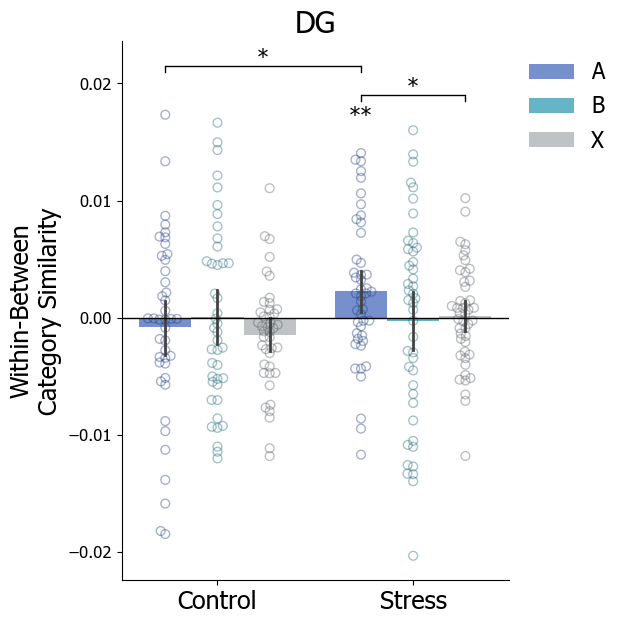

In [7]:
np.random.seed(0)

big = True

palette = ABX_colors
dark_palette = dark_ABX_colors


select_viz_df = coh_recog_df[['subid', 'group', 'cond', viz_y]]
select_viz_df = select_viz_df.groupby(["subid", "group", "cond"]).mean().reset_index()

if big:
    fig, ax = plt.subplots(1, 1, figsize=(5, 7))
else:
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 7))
    
sns.barplot(ax=ax, data=select_viz_df, x="group", y=viz_y, hue="cond", order=groups, hue_order=conds, palette=palette, errwidth=2, n_boot=9999)

if big:
    sns.swarmplot(ax=ax, data=select_viz_df, x="group", y=viz_y, hue="cond", order=groups, hue_order=conds, palette=dark_palette, dodge=True, alpha=0, s=4, legend=False)
else:
    sns.swarmplot(ax=ax, data=select_viz_df, x="group", y=viz_y, hue="cond", order=groups, hue_order=conds, palette=dark_palette, dodge=True, alpha=0, s=3, legend=False)

for groupi in range(len(groups)):
    for condi in range(len(conds)):
        i = groupi*len(conds) + condi
        x_data, y_data = ax.collections[i].get_offsets().T
    
        if big:
            ax.scatter(x_data, y_data, color="None", s=40, alpha=0.4, edgecolor=dark_palette[condi], linewidth=1)
        else:
            ax.scatter(x_data, y_data, color="None", s=20, alpha=0.4, edgecolor=dark_palette[condi], linewidth=1)

sns.despine()

ax.axhline(0, color='k', linewidth=1)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=16)
if viz_y == "PSS_coherence":
    ax.set_ylabel(f"Within-Between\nCategory Similarity", fontsize=18)
elif viz_y == "match_coherence":
    ax.set_ylabel(f"Within Category Similarity", fontsize=18)
elif viz_y == "nonmatch_coherence":
    ax.set_ylabel(f"Between Category Similarity", fontsize=18)
ax.set_xlabel('')
ax.set_xticklabels(groups, fontsize=18)
ax.set_title(roi, fontsize=22)



########################################
# add significant stars and bars
########################################
xcol="group"
huecol="cond"
valcol=viz_y
xorder=groups
hueorder=conds
bar_null=0
shifty_mult=0.06
stary_multshift=1
excl_marginal=True
onetail_hyp="above"

df_pivoted = select_viz_df.pivot(index=list(select_viz_df.columns[~np.isin(select_viz_df.columns, [xcol, huecol, valcol])]) + [xcol], columns=huecol, values=valcol).reset_index().dropna()
yshift = np.diff(ax.get_ylim())[0]*shifty_mult
max_stary_overall = 0

barxs = np.reshape([line.get_data()[0][0] for line in ax.get_lines()[:len(hueorder)*len(xorder)]], (len(hueorder), len(xorder))).T
barys = []
for hue in hueorder:
    for x in xorder:
        barys.append(np.max(select_viz_df.loc[(select_viz_df[xcol] == x) & (select_viz_df[huecol] == hue)][valcol]))
barys = np.reshape(barys, (len(hueorder), len(xorder))).T

for i in range(len(xorder)):
    max_stary = 0
    curx = xorder[i]

    # get data for this x
    x_df = df_pivoted.loc[(df_pivoted[xcol] == curx)]

    # compute single-bar stars:
    for j in range(len(hueorder)):
        curhue = hueorder[j]
        cur_data = np.array(x_df[curhue])

        CI, pval = simple_bootstrap(cur_data, null=bar_null, iterations=99999, onetail_hyp=onetail_hyp)
        rbc = wilcoxon_effsize(cur_data-bar_null, alternative=onetail_hyp, verbose=False)

        star = pval2star(pval)
        print(f"{curx} {curhue}: 95% CI {[f'{i:.8f}' for i in CI]}; p={pval:.5f}; r={rbc:.5f}")

        starx = barxs[i][j]
        stary = barys[i][j] + yshift

        if star != '':
            if excl_marginal and star == '~':
                continue
            if stary > max_stary:
                max_stary = stary

            if star != '':
                ax.text(s=star, x=starx, y=stary, fontsize=16, horizontalalignment="center")
            else:
                ax.text(s='n.s.', x=starx, y=stary+yshift*0.3, fontsize=12, horizontalalignment="center", verticalalignment='bottom')


    # compute within-group comparisons
    barpairs = list(combinations(np.arange(len(hueorder)), 2))
    pairord = np.argsort([np.diff(p)[0] for p in barpairs])
    barpairs_sorted = np.array(barpairs)[pairord]

    for pairidx in barpairs_sorted:
        condpair = np.array(hueorder)[pairidx]
        val1 = np.array(x_df[condpair[0]])
        val2 = np.array(x_df[condpair[1]])

        CI, pval = simple_bootstrap(val1 - val2, iterations=99999, onetail_hyp=onetail_hyp)
        rbc = wilcoxon_effsize(val1-val2, alternative=onetail_hyp, verbose=False)

        print(f"{curx} {condpair}: 95% CI {[f'{i:.8f}' for i in CI]}; p={f'{pval:.5f}'}; r={f'{rbc:.5f}'}")
        star = pval2star(pval)

        linex = barxs[i][pairidx]
        starx = np.mean(linex)
        stary = np.max(barys[i][pairidx]) + yshift

        if star != '':
            if excl_marginal and star == '~':
                continue

            if stary <= max_stary + yshift*stary_multshift:
                stary = max_stary + yshift*stary_multshift

            ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1)
            ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)
            ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)

            if star != '':
                ax.text(s=star, x=starx, y=stary, fontsize=16, horizontalalignment="center")
            else:
                ax.text(s='n.s.', x=starx, y=stary+yshift*0.3, fontsize=12, horizontalalignment="center", verticalalignment='bottom')

            if stary > max_stary:
                max_stary = stary


    if max_stary > max_stary_overall:
        max_stary_overall = max_stary

        
# compute between-group comparisons
for i in range(len(hueorder)):
    curhue = hueorder[i]

    # get data in each x for this hue
    xpair = np.array(xorder)[[1, 0]]
    # get data for these xs
    val1 = np.array(df_pivoted.loc[(df_pivoted[xcol] == xpair[0])][curhue])
    val2 = np.array(df_pivoted.loc[(df_pivoted[xcol] == xpair[1])][curhue])
    CI, pval = simple_bootstrap_2group(val1, val2, iterations=99999, null=0, onetail_hyp=onetail_hyp)
    rbc = mannwhitneyu_effsize(val1, val2, alternative=onetail_hyp, verbose=False)

    print(f"{curhue} {xpair}: 95% CI {[f'{i:.8f}' for i in CI]}; p={pval:.5f}; r={rbc:.5f}")
    star = pval2star(pval)
    linex = barxs.T[i][[1, 0]]
    starx = np.mean(linex)
    stary = np.max(barys.T[i][[1, 0]]) + yshift

    if star != '':
        if excl_marginal and star == '~':
            continue

        if stary <= max_stary_overall + yshift*stary_multshift:
            stary = max_stary_overall + yshift*stary_multshift

        ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1)
        ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)
        ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)

        if star != '':
            ax.text(s=star, x=starx, y=stary, fontsize=16, horizontalalignment="center")
        else:
            ax.text(s='n.s.', x=starx, y=stary+yshift*0.3, fontsize=12, horizontalalignment="center", verticalalignment='bottom')

        if stary > max_stary_overall:
            max_stary_overall = stary


ax.set_ylim(ax.get_ylim()[0], np.max([max_stary_overall, ax.get_ylim()[1]]))

plt.plot();


### Scanner effects

In [8]:
bw_first_sub = 56
scaneff_cond = "A"
scaneff_grp = "Stress"

bic_df = df_pivoted[df_pivoted["subid"] < bw_first_sub]
bw_df = df_pivoted[df_pivoted["subid"] >= bw_first_sub]

print(scaneff_grp)
bic_val = np.array(bic_df[bic_df["group"] == scaneff_grp][scaneff_cond])
bw_val = np.array(bw_df[bw_df["group"] == scaneff_grp][scaneff_cond])

print(scipy.stats.ttest_ind(bic_val, bw_val))
    

Stress
Ttest_indResult(statistic=0.5203914909674064, pvalue=0.605460008683116)


### Cortisol Effects

In [9]:
corteff_cond = "A"
catsim_df = df_pivoted[["subid", corteff_cond]].rename(columns={"subid": "subID"})
cort_df = pd.read_csv("./midpoints/summary/Day1_cortisol_react.csv")[["subID", "group", "cort_react"]]
merge_df = pd.merge(catsim_df, cort_df, on="subID", how="left")

r_lme(merge_df.dropna(), formula=f"{corteff_cond} ~ cort_react * group", random_formula="~ 1 | subID")

,numDF,denDF,F-value,p-value
(Intercept),1,70.0,0.115610,0.734864
cort_react,1,70.0,0.016638,0.897736
group,1,70.0,5.031703,0.028055
cort_react:group,1,70.0,0.291041,0.591266


## 4. Category evidence during learning (Figure 3C, Supplemental Figure S4)

By default, code in this section generates Figure 3C. To run supplemental analyses, edit parameters as follows:  
Supplemental Figure S4A: `roi = 'CA1'`  
Supplemental Figure S4B: `roi = 'CA23'`


Control A: 95% CI ['-0.00059752', '0.00103758']; p=0.33055; r=-0.03433
Control B: 95% CI ['-0.00124809', '0.00059462']; p=0.73623; r=-0.01440
Control X: 95% CI ['-0.00078735', '0.00065505']; p=0.54573; r=0.06091
Control ['A' 'B']: 95% CI ['-0.00073541', '0.00176674']; p=0.22669; r=0.06534
Control ['B' 'X']: 95% CI ['-0.00137673', '0.00076787']; p=0.66895; r=0.02104
Control ['A' 'X']: 95% CI ['-0.00093271', '0.00144468']; p=0.35302; r=0.00554
Stress A: 95% CI ['0.00053252', '0.00216095']; p=0.00040; r=0.42029
Stress B: 95% CI ['-0.00093343', '0.00082255']; p=0.55879; r=-0.06280
Stress X: 95% CI ['-0.00049908', '0.00072499']; p=0.35446; r=0.07053
Stress ['A' 'B']: 95% CI ['0.00011337', '0.00273068']; p=0.01569; r=0.30242
Stress ['B' 'X']: 95% CI ['-0.00123776', '0.00093021']; p=0.63317; r=-0.10338
Stress ['A' 'X']: 95% CI ['0.00026162', '0.00220024']; p=0.00625; r=0.40676
A ['Stress' 'Control']: 95% CI ['-0.00002145', '0.00229742']; p=0.02715; r=0.22540
B ['Stress' 'Control']: 95% CI ['-

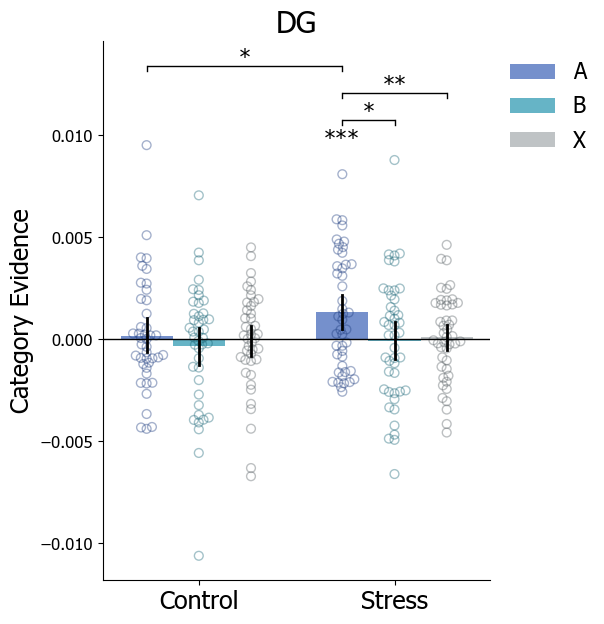

In [10]:
np.random.seed(0)

roi = "DG"
overwrite = False #recomputes instead of loading precomputed and saved df
palette = ABX_colors
dark_palette = dark_ABX_colors
big = True
fishertransform = True

match_runs = ['scene1']
learn_runs = ['scene2', 'scene3', 'scene4']
ABX_trialtype_bins = [[f'A{i+1}' for i in range(3)], [f'B{i+1}' for i in range(3)], [f'X{i+1}' for i in range(6)]]

if np.any(np.isin(match_runs, ['scene2', 'scene3', 'scene4'])) or np.any(np.isin(learn_runs, ['scene2', 'scene3', 'scene4'])):
    group_subIDs = [learn_ctrl_subIDs, learn_stress_subIDs]
else:
    group_subIDs = [ctrl_subIDs, stress_subIDs]

outfile = f"./midpoints/summary/{roi}_match{''.join([s[-1] for s in match_runs])}_cur{''.join(r[-1] for r in learn_runs)}_categoriness.csv"

if overwrite or not os.path.isfile(outfile):
    new_grp_corrs_df = {'subID': [], 'group': [], 'ABX': [], 'corr': []}

    for grp_subIDs, group_name in zip(group_subIDs, groups):
        for subid in grp_subIDs:
            print(subid, end=',')

            for trialtype_bin, abx in zip(ABX_trialtype_bins, conds):
                corrs = []

                for trialtype in trialtype_bin:
                    corrseries, _ = trialwise_corrseries(subid, roi, match_runs=match_runs, cur_runs=learn_runs, match_trialtypes=[trialtype], cur_trialtypes=[trialtype])
                    if fishertransform:
                        corrseries = np.arctanh(corrseries)
                    corrs.append(corrseries)

                corrs = np.concatenate(corrs)

                new_grp_corrs_df['subID'].append(subid)
                new_grp_corrs_df['group'].append(group_name)
                new_grp_corrs_df['ABX'].append(abx)
                new_grp_corrs_df['corr'].append(np.mean(corrs))

    new_grp_corrs_df = pd.DataFrame(new_grp_corrs_df)
    out_df = new_grp_corrs_df.pivot(index=["subID", "group"], columns="ABX", values="corr").reset_index()
    out_df.to_csv(outfile, index=False)

else:
    out_df = pd.read_csv(outfile)
    out_df = out_df[np.isin(out_df["subID"], subIDs)]
    new_grp_corrs_df = out_df.melt(id_vars = ["subID", "group"], value_vars=["A", "B", "X"], var_name="ABX", value_name="corr")


# Visualize
if big:
    fig, ax = plt.subplots(1, 1, figsize=(5, 7))
else:
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 7))

sns.barplot(ax=ax, data=new_grp_corrs_df, x="group", hue="ABX", y="corr", palette=palette, errwidth=2, errcolor='black', order=["Control", "Stress"], n_boot=9999)

if big:
    sns.swarmplot(ax=ax, data=new_grp_corrs_df, x="group", hue="ABX", y="corr", palette=dark_palette, order=["Control", "Stress"], dodge=True, s=4, alpha=0, legend=False)
else:
    sns.swarmplot(ax=ax, data=new_grp_corrs_df, x="group", hue="ABX", y="corr", palette=dark_palette, order=["Control", "Stress"], dodge=True, s=3, alpha=0, legend=False)


for groupi in range(len(groups)):
    for condi in range(len(conds)):
        i = groupi*len(conds) + condi
        x_data, y_data = ax.collections[i].get_offsets().T
    
        if big:
            ax.scatter(x_data, y_data, color="None", s=40, alpha=0.4, edgecolor=dark_palette[condi], linewidth=1)
        else:
            ax.scatter(x_data, y_data, color="None", s=20, alpha=0.4, edgecolor=dark_palette[condi], linewidth=1)

sns.despine()
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=16)
ax.axhline(0, color='k', linewidth=1)
ax.set_xlabel("")
ax.set_xticklabels(groups, fontsize=18)
if match_runs == ["scene1"]:
    ylabel = "Category Evidence"
elif match_runs == cur_runs:
    ylabel = "Within $-$ Between Category Similarity"
ax.set_ylabel(ylabel, fontsize=18)
ax.set_title(roi, fontsize=22)



########################################
# add significant stars and bars
########################################
corr_bycond = new_grp_corrs_df.pivot(index=["subID", "group"], columns="ABX", values="corr").reset_index()
corr_bycond_melt = corr_bycond.dropna().melt(id_vars=["subID", "group"], value_vars=["A", "B", "X"], var_name="ABX", value_name="corr").reset_index(drop=True)

xcol="group"
huecol="ABX"
valcol="corr"
xorder=groups
hueorder=conds
bar_null=0
shifty_mult=0.06
stary_multshift=1
excl_marginal=False
onetail_hyp="above"

df_pivoted = corr_bycond_melt.pivot(index=list(corr_bycond_melt.columns[~np.isin(corr_bycond_melt.columns, [xcol, huecol, valcol])]) + [xcol], columns=huecol, values=valcol).reset_index().dropna()
yshift = np.diff(ax.get_ylim())[0]*shifty_mult
max_stary_overall = 0

barxs = np.reshape([line.get_data()[0][0] for line in ax.get_lines()[:len(hueorder)*len(xorder)]], (len(hueorder), len(xorder))).T
barys = []
for hue in hueorder:
    for x in xorder:
        barys.append(np.max(corr_bycond_melt.loc[(corr_bycond_melt[xcol] == x) & (corr_bycond_melt[huecol] == hue)][valcol]))
barys = np.reshape(barys, (len(hueorder), len(xorder))).T

for i in range(len(xorder)):
    max_stary = 0
    curx = xorder[i]

    # get data for this x
    x_df = df_pivoted.loc[(df_pivoted[xcol] == curx)]

    # compute single-bar stars:
    for j in range(len(hueorder)):
        curhue = hueorder[j]
        cur_data = np.array(x_df[curhue])

        CI, pval = simple_bootstrap(cur_data, null=bar_null, iterations=99999, onetail_hyp=onetail_hyp)
        rbc = wilcoxon_effsize(cur_data-bar_null, alternative=onetail_hyp, verbose=False)

        star = pval2star(pval)
        print(f"{curx} {curhue}: 95% CI {[f'{i:.8f}' for i in CI]}; p={pval:.5f}; r={rbc:.5f}")

        starx = barxs[i][j]
        stary = barys[i][j] + yshift

        if star != '':
            if excl_marginal and star == '~':
                continue
            if stary > max_stary:
                max_stary = stary

            if star != '':
                ax.text(s=star, x=starx, y=stary, fontsize=16, horizontalalignment="center")
            else:
                ax.text(s='n.s.', x=starx, y=stary+yshift*0.3, fontsize=12, horizontalalignment="center", verticalalignment='bottom')



    # compute within-group comparisons
    barpairs = list(combinations(np.arange(len(hueorder)), 2))
    pairord = np.argsort([np.diff(p)[0] for p in barpairs])
    barpairs_sorted = np.array(barpairs)[pairord]

    for pairidx in barpairs_sorted:
        condpair = np.array(hueorder)[pairidx]
        val1 = np.array(x_df[condpair[0]])
        val2 = np.array(x_df[condpair[1]])

        CI, pval = simple_bootstrap(val1 - val2, iterations=99999, onetail_hyp=onetail_hyp)
        rbc = wilcoxon_effsize(val1-val2, alternative=onetail_hyp, verbose=False)

        print(f"{curx} {condpair}: 95% CI {[f'{i:.8f}' for i in CI]}; p={f'{pval:.5f}'}; r={f'{rbc:.5f}'}")
        star = pval2star(pval)

        linex = barxs[i][pairidx]
        starx = np.mean(linex)
        stary = np.max(barys[i][pairidx]) + yshift

        if star != '':
            if excl_marginal and star == '~':
                continue

            if stary <= max_stary + yshift*stary_multshift:
                stary = max_stary + yshift*stary_multshift

            ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1)
            ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)
            ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)

            if star != '':
                ax.text(s=star, x=starx, y=stary, fontsize=16, horizontalalignment="center")
            else:
                ax.text(s='n.s.', x=starx, y=stary+yshift*0.3, fontsize=12, horizontalalignment="center", verticalalignment='bottom')

            if stary > max_stary:
                max_stary = stary


    if max_stary > max_stary_overall:
        max_stary_overall = max_stary

        
# compute between-group comparisons
for i in range(len(hueorder)):
    curhue = hueorder[i]

    # get data in each x for this hue
    xpair = np.array(xorder)[[1, 0]]
    # get data for these xs
    val1 = np.array(df_pivoted.loc[(df_pivoted[xcol] == xpair[0])][curhue])
    val2 = np.array(df_pivoted.loc[(df_pivoted[xcol] == xpair[1])][curhue])
    CI, pval = simple_bootstrap_2group(val1, val2, iterations=99999, null=0, onetail_hyp=onetail_hyp)
    rbc = mannwhitneyu_effsize(val1, val2, alternative=onetail_hyp, verbose=False)

    print(f"{curhue} {xpair}: 95% CI {[f'{i:.8f}' for i in CI]}; p={pval:.5f}; r={rbc:.5f}")
    star = pval2star(pval)
    linex = barxs.T[i][[1, 0]]
    starx = np.mean(linex)
    stary = np.max(barys.T[i][[1, 0]]) + yshift

    if star != '':
        if excl_marginal and star == '~':
            continue

        if stary <= max_stary_overall + yshift*stary_multshift:
            stary = max_stary_overall + yshift*stary_multshift

        ax.hlines(y=stary, xmin=linex[0], xmax=linex[1], color='k', linewidth=1)
        ax.vlines(x=linex[0], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)
        ax.vlines(x=linex[1], ymin=stary-yshift*0.2, ymax=stary, color='k', capstyle='projecting', linewidth=1)

        if star != '':
            ax.text(s=star, x=starx, y=stary, fontsize=16, horizontalalignment="center")
        else:
            ax.text(s='n.s.', x=starx, y=stary+yshift*0.3, fontsize=12, horizontalalignment="center", verticalalignment='bottom')

        if stary > max_stary_overall:
            max_stary_overall = stary


ax.set_ylim(ax.get_ylim()[0], np.max([max_stary_overall, ax.get_ylim()[1]]))

plt.plot();


### Scanner effects

In [11]:
bw_first_sub = 56
scaneff_cond = "A"
scaneff_grp = "Stress"

bic_df = df_pivoted[df_pivoted["subID"] < bw_first_sub]
bw_df = df_pivoted[df_pivoted["subID"] >= bw_first_sub]

print(scaneff_grp)
bic_val = np.array(bic_df[bic_df["group"] == scaneff_grp][scaneff_cond])
bw_val = np.array(bw_df[bw_df["group"] == scaneff_grp][scaneff_cond])

print(scipy.stats.ttest_ind(bic_val, bw_val))
    

Stress
Ttest_indResult(statistic=-0.2211439747574055, pvalue=0.8260271166000166)


### Cortisol Effects

In [12]:
corteff_cond = "A"
catev_df = df_pivoted[["subID", corteff_cond]]
cort_df = pd.read_csv("./midpoints/summary/Day1_cortisol_react.csv")[["subID", "group", "cort_react"]]
merge_df = pd.merge(catev_df, cort_df, on="subID", how="left")

r_lme(merge_df.dropna(), formula=f"{corteff_cond} ~ cort_react * group", random_formula="~ 1 | subID")

,numDF,denDF,F-value,p-value
(Intercept),1,70.0,3.955362,0.050632
cort_react,1,70.0,0.630282,0.429935
group,1,70.0,3.048374,0.085205
cort_react:group,1,70.0,0.006084,0.938049


## 5. Relationship between category evidence and prediction (Figure 3D)

Control:
r=0.2915205191426844
95% CI [0.017535749683209364, 0.5247392888623149]; p=0.037803780378037805

Stress:
r=0.34524418632356546
95% CI [0.049379546455962126, 0.5706740898243612]; p=0.024002400240024



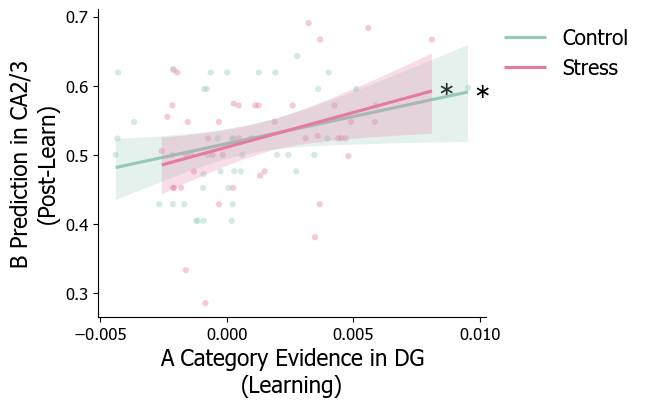

In [13]:
classifier_df = pd.read_csv("./midpoints/summary/classifier_besthyperparams_CA23.csv")[["subID", "B_prediction"]]
catev_df = pd.read_csv("./midpoints/summary/DG_match1_cur234_categoriness.csv")[["subID", "group", "A"]]
merge_df = pd.merge(catev_df, classifier_df, on="subID", how="left")

np.random.seed(0)
ax = plot_lm(df=merge_df, xvar="A", yvar="B_prediction", groups=["Control", "Stress"], figsize=(5, 4),
             pretty=True, legend=True, boot=True, verbose=False)
ax.set_xlabel('A Category Evidence in DG\n(Learning)', fontsize=16)
ax.set_ylabel('B Prediction in CA2/3\n(Post-Learn)', fontsize=16)
ax.set_yticks(np.arange(0.3, 0.71, 0.1), fontsize=14)
ax.set_xticks(np.arange(-0.005, 0.011, 0.005), fontsize=14)

plt.show();


## 6. Relationship between category evidence and false alarms (Figure 3E)

Control:
r=0.018624054812114373
95% CI [-0.2648056906018382, 0.3393510676867492]; p=0.8960896089608961

Stress:
r=0.3240434224952
95% CI [0.017008450414240744, 0.5709154055263901]; p=0.04020402040204021



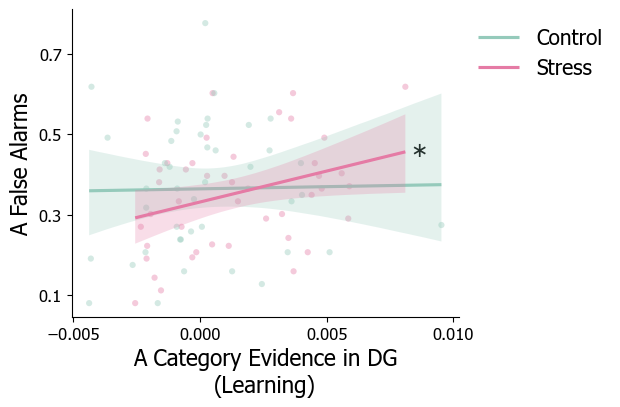

In [14]:
fa_df = pd.read_csv("./midpoints/behavior/behav_recog.csv")[["subID", "FA_A"]]
catev_df = pd.read_csv("./midpoints/summary/DG_match1_cur234_categoriness.csv")[["subID", "group", "A"]]
merge_df = pd.merge(catev_df, fa_df, on="subID", how="left")

np.random.seed(0)
ax = plot_lm(df=merge_df, xvar="A", yvar="FA_A", groups=["Control", "Stress"], figsize=(5, 4),
             pretty=True, legend=True, boot=True, verbose=False)
ax.set_xlabel('A Category Evidence in DG\n(Learning)', fontsize=16)
ax.set_ylabel('A False Alarms', fontsize=16)
ax.set_yticks(np.arange(0.1, 0.71, 0.2), fontsize=14)
ax.set_xticks(np.arange(-0.005, 0.011, 0.005), fontsize=14)

plt.show();
